# H0/H1 Logistic Regression Reproduction

This notebook reproduces the historical Logistic Regression
experiments from the original coursework under the revised
patient-aware validation framework.

- H0: unweighted Logistic Regression lower bound.
- H1: class-weighted Logistic Regression from the main assessment.

Both models are evaluated on the same fixed Fold 0 validation set
used by all later LSA models.

Logistic Regression uses grayscale 64x64 images flattened into
4,096 normalized pixel features.

In [4]:
from pathlib import Path
import json
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from PIL import Image
from tqdm.auto import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)
from sklearn.exceptions import ConvergenceWarning


cwd = Path.cwd()

if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError(
        "Could not locate project root."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

from src.evaluate import (
    calculate_binary_metrics,
    make_prediction_dataframe,
    save_metrics_json,
)


DATA_DIR = PROJECT_ROOT / "data"
IMAGE_DIR = DATA_DIR / "train_images"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
PREDICTION_DIR = OUTPUT_DIR / "predictions"
FIGURE_DIR = OUTPUT_DIR / "figures"

LOG_DIR = PROJECT_ROOT / "logs"

PREDICTION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\test\Documents\EEEM068_LSA_Melanoma


## Load fixed patient-aware split

In [5]:
df = pd.read_csv(
    DATA_DIR / "train.csv"
)

folds = pd.read_csv(
    DATA_DIR / "train_folds.csv"
)

df = df.merge(
    folds,
    on="image_name",
    how="left",
    validate="one_to_one",
)

assert df["fold"].isna().sum() == 0

df["image_path"] = df["image_name"].apply(
    lambda image_name:
        IMAGE_DIR / f"{image_name}.jpg"
)

TRAIN_FOLD = 0

train_df = (
    df[df["fold"] != TRAIN_FOLD]
    .copy()
    .reset_index(drop=True)
)

val_df = (
    df[df["fold"] == TRAIN_FOLD]
    .copy()
    .reset_index(drop=True)
)

print("Training:", len(train_df))
print("Validation:", len(val_df))

print("\nTraining targets:")
print(
    train_df["target"]
    .value_counts()
    .sort_index()
)

print("\nValidation targets:")
print(
    val_df["target"]
    .value_counts()
    .sort_index()
)

Training: 26499
Validation: 6627

Training targets:
target
0    26032
1      467
Name: count, dtype: int64

Validation targets:
target
0    6510
1     117
Name: count, dtype: int64


In [6]:
train_patients = set(
    train_df["patient_id"]
)

val_patients = set(
    val_df["patient_id"]
)

overlap = (
    train_patients
    .intersection(val_patients)
)

print(
    "Patient overlap:",
    len(overlap),
)

assert len(overlap) == 0

Patient overlap: 0


## Historical 5,000-image Logistic Regression training subset

In [7]:
lr_train_df, _ = train_test_split(
    train_df,
    train_size=5000,
    stratify=train_df["target"],
    random_state=42,
)

lr_train_df = (
    lr_train_df
    .copy()
    .reset_index(drop=True)
)

print(
    "LR training subset:",
    len(lr_train_df),
)

print(
    lr_train_df["target"]
    .value_counts()
    .sort_index()
)

LR training subset: 5000
target
0    4912
1      88
Name: count, dtype: int64


In [8]:
lr_subset_manifest = (
    lr_train_df[
        [
            "image_name",
            "target",
        ]
    ]
    .copy()
)

lr_subset_path = (
    DATA_DIR
    / "lr_train_subset.csv"
)

lr_subset_manifest.to_csv(
    lr_subset_path,
    index=False,
)

print(
    "Saved:",
    lr_subset_path,
)

Saved: c:\Users\test\Documents\EEEM068_LSA_Melanoma\data\lr_train_subset.csv


## Grayscale pixel feature extraction

In [9]:
def extract_logistic_features(
    dataframe,
    image_size=(64, 64),
):
    """
    Convert each JPEG into a flattened grayscale vector.

    Processing:
    RGB/JPEG
    -> grayscale
    -> 64x64 resize
    -> float32
    -> scale to [0, 1]
    -> flatten to 4096 features
    """

    n_samples = len(dataframe)
    n_features = (
        image_size[0]
        * image_size[1]
    )

    X = np.empty(
        (
            n_samples,
            n_features,
        ),
        dtype=np.float32,
    )

    for i, image_path in enumerate(
        tqdm(
            dataframe["image_path"],
            total=n_samples,
        )
    ):
        with Image.open(
            image_path
        ) as image:

            image = image.convert(
                "L"
            )

            image = image.resize(
                image_size,
                Image.Resampling.BILINEAR,
            )

            pixels = np.asarray(
                image,
                dtype=np.float32,
            )

            X[i] = (
                pixels.reshape(-1)
                / 255.0
            )

    y = (
        dataframe["target"]
        .to_numpy(dtype=np.int64)
    )

    return X, y

In [10]:
X_train, y_train = (
    extract_logistic_features(
        lr_train_df
    )
)

X_val, y_val = (
    extract_logistic_features(
        val_df
    )
)

print(
    "X_train:",
    X_train.shape,
)

print(
    "X_val:",
    X_val.shape,
)

print(
    "Feature dtype:",
    X_train.dtype,
)

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/6627 [00:00<?, ?it/s]

X_train: (5000, 4096)
X_val: (6627, 4096)
Feature dtype: float32


## H0 — Unweighted Logistic Regression

In [11]:
h0_model = LogisticRegression(
    solver="lbfgs",
    penalty="l2",
    C=1.0,
    class_weight=None,
    max_iter=1000,
    random_state=42,
)

start_time = time.perf_counter()

with warnings.catch_warnings(
    record=True
) as h0_warnings:

    warnings.simplefilter(
        "always"
    )

    h0_model.fit(
        X_train,
        y_train,
    )

h0_seconds = (
    time.perf_counter()
    - start_time
)

h0_prob = (
    h0_model.predict_proba(
        X_val
    )[:, 1]
)

h0_metrics = (
    calculate_binary_metrics(
        y_val,
        h0_prob,
        threshold=0.5,
    )
)

print(
    json.dumps(
        h0_metrics,
        indent=2,
    )
)

print(
    "Fit time:",
    round(
        h0_seconds,
        2,
    ),
    "seconds",
)

print(
    "Iterations:",
    h0_model.n_iter_,
)

print(
    "Warnings:",
    [
        str(w.message)
        for w in h0_warnings
    ],
)

{
  "threshold": 0.5,
  "roc_auc": 0.6570220699252958,
  "pr_auc_average_precision": 0.03859192498149585,
  "accuracy": 0.980986871887732,
  "balanced_accuracy": 0.5035054551183583,
  "precision": 0.09090909090909091,
  "sensitivity": 0.008547008547008548,
  "recall": 0.008547008547008548,
  "specificity": 0.9984639016897081,
  "f1": 0.015625,
  "tn": 6500,
  "fp": 10,
  "fn": 116,
  "tp": 1,
  "n_samples": 6627,
  "n_positive": 117,
  "n_negative": 6510
}
Fit time: 1.15 seconds
Iterations: [82]
Warnings: ["'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None."]


In [12]:
h0_log_dir = (
    LOG_DIR
    / "H0_logistic_unweighted"
)

h0_log_dir.mkdir(
    parents=True,
    exist_ok=True,
)


h0_predictions = (
    make_prediction_dataframe(
        val_df,
        y_val,
        h0_prob,
        threshold=0.5,
    )
)

h0_predictions.to_csv(
    PREDICTION_DIR
    / "H0_logistic_unweighted.csv",
    index=False,
)

save_metrics_json(
    h0_metrics,
    h0_log_dir
    / "metrics.json",
)


h0_config = {
    "experiment_id": "H0",
    "model": "LogisticRegression",
    "class_weight": None,
    "solver": "lbfgs",
    "penalty": "l2",
    "C": 1.0,
    "max_iter": 1000,
    "random_state": 42,
    "training_subset_size": 5000,
    "training_subset_seed": 42,
    "validation_fold": 0,
    "feature_representation":
        "64x64 grayscale flattened pixels",
    "feature_dimension": 4096,
    "pixel_scaling":
        "divide_by_255",
    "threshold": 0.5,
    "fit_seconds": h0_seconds,
    "n_iter": int(
        h0_model.n_iter_[0]
    ),
}

with open(
    h0_log_dir
    / "config.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        h0_config,
        f,
        indent=2,
    )


with open(
    h0_log_dir
    / "experiment.log",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        "H0 - Unweighted Logistic Regression\n"
    )
    f.write(
        f"Training subset: {len(lr_train_df)}\n"
    )
    f.write(
        f"Validation samples: {len(val_df)}\n"
    )
    f.write(
        f"Fit seconds: {h0_seconds:.2f}\n"
    )
    f.write(
        f"Iterations: {h0_model.n_iter_[0]}\n"
    )
    f.write(
        f"Warnings: {[str(w.message) for w in h0_warnings]}\n"
    )

## H1 — Class-weighted Logistic Regression

In [13]:
h1_model = LogisticRegression(
    solver="lbfgs",
    penalty="l2",
    C=1.0,
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
)

start_time = time.perf_counter()

with warnings.catch_warnings(
    record=True
) as h1_warnings:

    warnings.simplefilter(
        "always"
    )

    h1_model.fit(
        X_train,
        y_train,
    )

h1_seconds = (
    time.perf_counter()
    - start_time
)

h1_prob = (
    h1_model.predict_proba(
        X_val
    )[:, 1]
)

h1_metrics = (
    calculate_binary_metrics(
        y_val,
        h1_prob,
        threshold=0.5,
    )
)

print(
    json.dumps(
        h1_metrics,
        indent=2,
    )
)

print(
    "Fit time:",
    round(
        h1_seconds,
        2,
    ),
    "seconds",
)

print(
    "Iterations:",
    h1_model.n_iter_,
)

print(
    "Warnings:",
    [
        str(w.message)
        for w in h1_warnings
    ],
)

{
  "threshold": 0.5,
  "roc_auc": 0.6243924534247115,
  "pr_auc_average_precision": 0.036315504860682926,
  "accuracy": 0.9372264976610835,
  "balanced_accuracy": 0.5483792193469613,
  "precision": 0.05105105105105105,
  "sensitivity": 0.1452991452991453,
  "recall": 0.1452991452991453,
  "specificity": 0.9514592933947773,
  "f1": 0.07555555555555556,
  "tn": 6194,
  "fp": 316,
  "fn": 100,
  "tp": 17,
  "n_samples": 6627,
  "n_positive": 117,
  "n_negative": 6510
}
Fit time: 3.96 seconds
Iterations: [338]
Warnings: ["'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None."]


In [14]:
h1_metrics_threshold_03 = (
    calculate_binary_metrics(
        y_val,
        h1_prob,
        threshold=0.3,
    )
)

print(
    "H1 @ threshold 0.5"
)

print(
    json.dumps(
        h1_metrics,
        indent=2,
    )
)

print(
    "\nH1 @ threshold 0.3"
)

print(
    json.dumps(
        h1_metrics_threshold_03,
        indent=2,
    )
)

H1 @ threshold 0.5
{
  "threshold": 0.5,
  "roc_auc": 0.6243924534247115,
  "pr_auc_average_precision": 0.036315504860682926,
  "accuracy": 0.9372264976610835,
  "balanced_accuracy": 0.5483792193469613,
  "precision": 0.05105105105105105,
  "sensitivity": 0.1452991452991453,
  "recall": 0.1452991452991453,
  "specificity": 0.9514592933947773,
  "f1": 0.07555555555555556,
  "tn": 6194,
  "fp": 316,
  "fn": 100,
  "tp": 17,
  "n_samples": 6627,
  "n_positive": 117,
  "n_negative": 6510
}

H1 @ threshold 0.3
{
  "threshold": 0.3,
  "roc_auc": 0.6243924534247115,
  "pr_auc_average_precision": 0.036315504860682926,
  "accuracy": 0.8922589406971481,
  "balanced_accuracy": 0.5716550474614991,
  "precision": 0.042879019908116385,
  "sensitivity": 0.23931623931623933,
  "recall": 0.23931623931623933,
  "specificity": 0.9039938556067588,
  "f1": 0.07272727272727272,
  "tn": 5885,
  "fp": 625,
  "fn": 89,
  "tp": 28,
  "n_samples": 6627,
  "n_positive": 117,
  "n_negative": 6510
}


In [15]:
h1_log_dir = (
    LOG_DIR
    / "H1_logistic_weighted"
)

h1_log_dir.mkdir(
    parents=True,
    exist_ok=True,
)


h1_predictions = (
    make_prediction_dataframe(
        val_df,
        y_val,
        h1_prob,
        threshold=0.5,
    )
)

h1_predictions.to_csv(
    PREDICTION_DIR
    / "H1_logistic_weighted.csv",
    index=False,
)


save_metrics_json(
    h1_metrics,
    h1_log_dir
    / "metrics.json",
)


save_metrics_json(
    h1_metrics_threshold_03,
    h1_log_dir
    / "metrics_threshold_0.3.json",
)


h1_config = {
    "experiment_id": "H1",
    "model": "LogisticRegression",
    "class_weight": "balanced",
    "solver": "lbfgs",
    "penalty": "l2",
    "C": 1.0,
    "max_iter": 1000,
    "random_state": 42,
    "training_subset_size": 5000,
    "training_subset_seed": 42,
    "validation_fold": 0,
    "feature_representation":
        "64x64 grayscale flattened pixels",
    "feature_dimension": 4096,
    "pixel_scaling":
        "divide_by_255",
    "primary_threshold": 0.5,
    "historical_threshold": 0.3,
    "fit_seconds": h1_seconds,
    "n_iter": int(
        h1_model.n_iter_[0]
    ),
}


with open(
    h1_log_dir
    / "config.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        h1_config,
        f,
        indent=2,
    )


with open(
    h1_log_dir
    / "experiment.log",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        "H1 - Class-weighted Logistic Regression\n"
    )
    f.write(
        f"Training subset: {len(lr_train_df)}\n"
    )
    f.write(
        f"Validation samples: {len(val_df)}\n"
    )
    f.write(
        f"Fit seconds: {h1_seconds:.2f}\n"
    )
    f.write(
        f"Iterations: {h1_model.n_iter_[0]}\n"
    )
    f.write(
        f"Warnings: {[str(w.message) for w in h1_warnings]}\n"
    )

In [16]:
comparison = pd.DataFrame(
    [
        {
            "Experiment": "H0",
            **h0_metrics,
        },
        {
            "Experiment": "H1",
            **h1_metrics,
        },
        {
            "Experiment":
                "H1 threshold=0.3",
            **h1_metrics_threshold_03,
        },
    ]
)

columns_to_show = [
    "Experiment",
    "threshold",
    "roc_auc",
    "pr_auc_average_precision",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "sensitivity",
    "specificity",
    "f1",
    "tn",
    "fp",
    "fn",
    "tp",
]

display(
    comparison[
        columns_to_show
    ]
)

,Experiment,threshold,roc_auc,pr_auc_average_precision,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,tn,fp,fn,tp
0,H0,0.5,0.657022,0.038592,0.980987,0.503505,0.090909,0.008547,0.998464,0.015625,6500,10,116,1
1,H1,0.5,0.624392,0.036316,0.937226,0.548379,0.051051,0.145299,0.951459,0.075556,6194,316,100,17
2,H1 threshold=0.3,0.3,0.624392,0.036316,0.892259,0.571655,0.042879,0.239316,0.903994,0.072727,5885,625,89,28


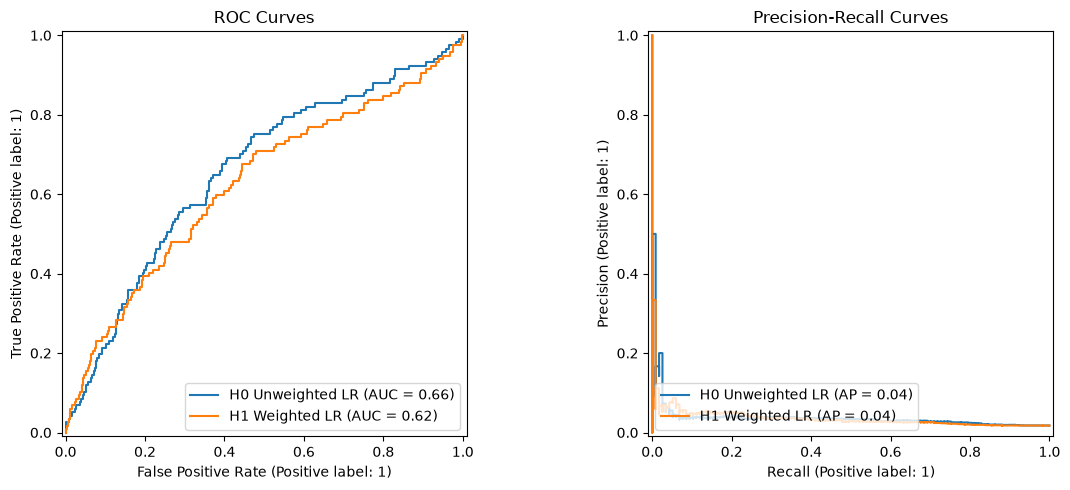

In [17]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
)

RocCurveDisplay.from_predictions(
    y_val,
    h0_prob,
    name="H0 Unweighted LR",
    ax=axes[0],
)

RocCurveDisplay.from_predictions(
    y_val,
    h1_prob,
    name="H1 Weighted LR",
    ax=axes[0],
)

axes[0].set_title(
    "ROC Curves"
)


PrecisionRecallDisplay.from_predictions(
    y_val,
    h0_prob,
    name="H0 Unweighted LR",
    ax=axes[1],
)

PrecisionRecallDisplay.from_predictions(
    y_val,
    h1_prob,
    name="H1 Weighted LR",
    ax=axes[1],
)

axes[1].set_title(
    "Precision-Recall Curves"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "logistic_roc_pr.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

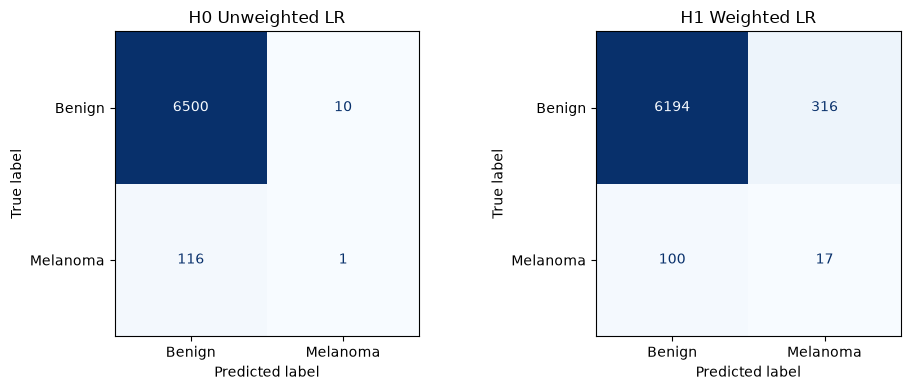

In [18]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
)

h0_pred = (
    h0_prob >= 0.5
).astype(int)

h1_pred = (
    h1_prob >= 0.5
).astype(int)


ConfusionMatrixDisplay.from_predictions(
    y_val,
    h0_pred,
    display_labels=[
        "Benign",
        "Melanoma",
    ],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)

axes[0].set_title(
    "H0 Unweighted LR"
)


ConfusionMatrixDisplay.from_predictions(
    y_val,
    h1_pred,
    display_labels=[
        "Benign",
        "Melanoma",
    ],
    cmap="Blues",
    ax=axes[1],
    colorbar=False,
)

axes[1].set_title(
    "H1 Weighted LR"
)


plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "logistic_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Observations

At the common threshold of 0.5, the unweighted Logistic
Regression model achieved ROC-AUC 0.657 and melanoma
sensitivity 0.9%.

Applying balanced class weights changed sensitivity from
0.9% to 14.5% and specificity from 99.8% to 95.1%.

The ROC-AUC decreased from 0.657 to 0.624, indicating that
class weighting did not improve the overall probability
ranking of malignant versus benign lesions. Although weighting
improved melanoma detection at the common threshold, this came
with more false positives and lower specificity.

Lowering the weighted model's threshold from 0.5 to 0.3
changed sensitivity from 14.5% to 23.9% while specificity
changed from 95.1% to 90.4%, illustrating the trade-off between
detecting more melanomas and misclassifying more benign lesions.

These results demonstrate that loss/class weighting and
decision-threshold adjustment affect different aspects of
classifier behaviour. Weighting changes the fitted model,
whereas threshold adjustment changes the operating point
applied to an already fitted probability model.

Average Precision (AP) was 0.039 for H0 and 0.036 for H1; this metric is
particularly informative given the 1.76% melanoma prevalence.

The Logistic Regression models remain limited because
flattened grayscale pixels remove colour information and
provide no explicit mechanism for learning local or
hierarchical spatial features.